In [1]:
"""
Final Model — Prediction & Coefficient Breakdown for Patients 120 and 73
============================================================================
Trains the final Logistic Regression model on the final 21-feature
dataset and produces, for patient indices 120 and 73:
 
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import FancyBboxPatch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH    = "Data for Task 1.csv"
TARGET_COL   = "diagnosis"
DROP_COLS    = ["id", "Unnamed: 32"]
THRESHOLD    = 0.35
RANDOM_STATE = 42
 
FINAL_FEATURES = [
    "radius_mean", "radius_se", "radius_worst",
    "compactness_mean", "compactness_se", "compactness_worst",
    "texture_mean", "texture_se", "texture_worst",
    "concavity_mean", "concavity_se", "concavity_worst",
    "smoothness_mean", "smoothness_se", "smoothness_worst",
    "symmetry_mean", "symmetry_se", "symmetry_worst",
    "fractal_dimension_mean", "fractal_dimension_se", "fractal_dimension_worst",
]
 
PATIENT_INDICES = [120, 73]

In [3]:
BG          = "#f5f4f0"
CARD        = "#ffffff"
CARD_BORDER = "#d9d8d2"
TEAL        = "#1D9E75"   
CORAL       = "#D85A30"   
TEXT_PRIMARY   = "#1a1a18"
TEXT_SECONDARY = "#5f5e5a"
TEXT_LABEL     = "#888780"
 
FONT_CANDIDATES = ["Helvetica Neue", "Arial", "DejaVu Sans"]
AVAILABLE_FONTS = {f.name for f in fm.fontManager.ttflist}
FONT_FAMILY = next((f for f in FONT_CANDIDATES if f in AVAILABLE_FONTS), "DejaVu Sans")
 
plt.rcParams.update({
    "font.family":       FONT_FAMILY,
    "text.color":        TEXT_PRIMARY,
    "axes.edgecolor":    CARD_BORDER,
    "axes.labelcolor":   TEXT_SECONDARY,
    "xtick.color":       TEXT_SECONDARY,
    "ytick.color":       TEXT_SECONDARY,
    "figure.facecolor":  BG,
    "savefig.facecolor": BG,
})

In [4]:
def train_final_model():
    df = pd.read_csv(DATA_PATH)
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
 
    y_str = df[TARGET_COL]
    X = df[FINAL_FEATURES]
 
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y_str, test_size=0.2, random_state=RANDOM_STATE, stratify=y_str
    )
 
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_raw)
    X_test_sc  = scaler.transform(X_test_raw)
 
    model = LogisticRegression(
        C=1.0, solver="lbfgs", max_iter=10000,
        class_weight="balanced", random_state=RANDOM_STATE
    )
    model.fit(X_train_sc, y_train)
 
    return model, scaler, X, X_train_raw, X_test_raw, y_train, y_test

In [5]:
def explain_patient(model, scaler, feature_names, patient_row_raw, threshold=THRESHOLD):
    raw_values   = patient_row_raw[feature_names].values.reshape(1, -1)
    standardised = scaler.transform(raw_values)[0]
 
    coefficients  = model.coef_[0]
    contributions = coefficients * standardised
 
    breakdown = pd.DataFrame({
        "feature":      feature_names,
        "raw_value":    raw_values[0],
        "standardised": standardised,
        "coefficient":  coefficients,
        "contribution": contributions,
    }).sort_values("contribution", key=abs, ascending=False).reset_index(drop=True)
 
    prob_malignant = model.predict_proba(standardised.reshape(1, -1))[0, 1]
    prediction = "M" if prob_malignant >= threshold else "B"
 
    return {
        "probability_malignant": prob_malignant,
        "prediction": prediction,
        "threshold_used": threshold,
        "breakdown": breakdown,
    }
 
 
def print_explanation(patient_index, true_label, result, top_n=8):
    print(f"=== Patient at index {patient_index} ===")
    print(f"True diagnosis: {true_label}")
    print(f"Predicted probability of malignancy: {result['probability_malignant']:.4f} "
          f"({result['probability_malignant']:.1%})")
    print(f"Classification at threshold={result['threshold_used']}: {result['prediction']}")
    correct = "✓ correct" if result["prediction"] == true_label else "✗ INCORRECT"
    print(f"Result: {correct}\n")
 
    print(f"Top {top_n} features by contribution (coefficient x standardised value):")
    print(f"  {'Feature':<26} {'Raw value':>10} {'Coefficient':>12} {'Contribution':>13}")
    print("  " + "-" * 65)
    for _, row in result["breakdown"].head(top_n).iterrows():
        direction = "↑ malignant" if row["contribution"] > 0 else "↓ malignant"
        print(f"  {row['feature']:<26} {row['raw_value']:>10.3f} "
              f"{row['coefficient']:>+12.3f} {row['contribution']:>+13.3f}  {direction}")
    print()

In [36]:
def add_card(fig, ax, pad=0.02):
    bbox = ax.get_position()
    card = FancyBboxPatch(
        (bbox.x0 - pad, bbox.y0 - pad),
        bbox.width + 2 * pad, bbox.height + 1.5 * pad,
        boxstyle="round,pad=0,rounding_size=0.02",
        transform=fig.transFigure,
        facecolor=CARD, edgecolor=CARD_BORDER, linewidth=0.8, zorder=-1
    )
    fig.add_artist(card)
 
 
def plot_patient_contributions(patient_index, true_label, result, top_n=10, save_path=None):
    df_top = result["breakdown"].head(top_n).copy()
    df_top = df_top.sort_values("contribution", key=abs, ascending=True)
 
    n = len(df_top)
    fig, ax = plt.subplots(figsize=(9, 0.65 * n + 2.0), facecolor=BG)
    fig.subplots_adjust(left=0.38, right=0.93, top=0.80, bottom=0.14)
 
    y_pos = np.arange(n)*0.6
    colors = [CORAL if c > 0 else TEAL for c in df_top["contribution"]]
 
    ax.barh(y_pos, df_top["contribution"], color=colors, height=0.4, zorder=2)
    ax.axvline(0, color=CARD_BORDER, linewidth=0.8, alpha=0.6, zorder=1,)
 
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top["feature"], fontsize=8)
    ax.tick_params(axis='y', pad=20)
    ax.tick_params(axis='x', labelsize=8)
    ax.set_xlabel("Contribution to malignancy log-odds",
                 fontsize=8, color=TEXT_LABEL)
 
    for y, c in zip(y_pos, df_top["contribution"]):
        offset = 0.04 * max(abs(df_top["contribution"]).max(), 0.1)
        ha = "left" if c > 0 else "right"
        ax.text(c + (offset if c > 0 else -offset), y, f"{c:+.2f}",
               va="center", ha=ha, fontsize=8.5, color=TEXT_SECONDARY, fontweight=500)
 
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(CARD_BORDER)
    ax.tick_params(length=0)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.5, alpha=0.35, zorder=0)
    ax.set_axisbelow(True)
 
    xmax = max(abs(df_top["contribution"]).max() * 1.4, 0.5)
    ax.set_xlim(-xmax, xmax)
 
    prob = result["probability_malignant"]
    pred = result["prediction"]
    correct_str = "correct" if pred == true_label else "INCORRECT"
    title = (f"Patient {patient_index} — predicted {prob:.1%} malignancy risk "
            f"→ classified {pred} ({correct_str})")
    ax.set_title(title, fontsize=9, fontweight=600, color=TEXT_PRIMARY,
                loc="left", pad=20)
 
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=CORAL, label="Pushes toward malignant"),
        plt.Rectangle((0, 0), 1, 1, color=TEAL,  label="Pushes toward benign"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.066),
             frameon=False, fontsize=8, labelcolor=TEXT_SECONDARY, ncol=2)
 
    fig.canvas.draw()
    add_card(fig, ax)
 
    if save_path:
        fig.savefig(save_path, dpi=180, facecolor=BG, bbox_inches="tight", pad_inches=0.3)
        print(f"Saved: {save_path}")
 
    return fig

=== Patient at index 120 ===
True diagnosis: B
Predicted probability of malignancy: 0.0009 (0.1%)
Classification at threshold=0.35: B
Result: ✓ correct

Top 8 features by contribution (coefficient x standardised value):
  Feature                     Raw value  Coefficient  Contribution
  -----------------------------------------------------------------
  texture_worst                  15.970       +1.391        -2.276  ↓ malignant
  radius_se                       0.141       +2.171        -2.025  ↓ malignant
  radius_worst                   12.820       +1.900        -1.371  ↓ malignant
  radius_mean                    11.410       +1.421        -1.096  ↓ malignant
  concavity_mean                  0.035       +1.404        -0.930  ↓ malignant
  texture_mean                   10.820       +0.399        -0.801  ↓ malignant
  texture_se                      0.461       -0.408        +0.560  ↑ malignant
  compactness_se                  0.015       -0.713        +0.406  ↑ malignant

Save

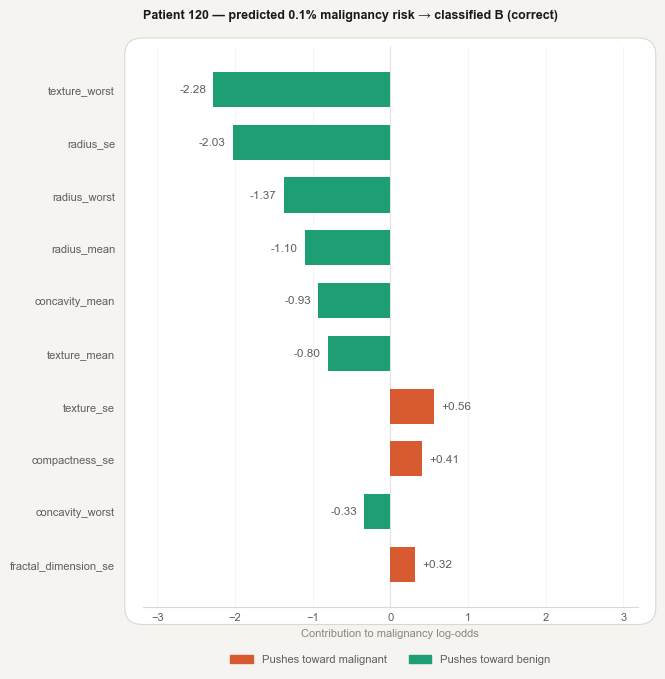

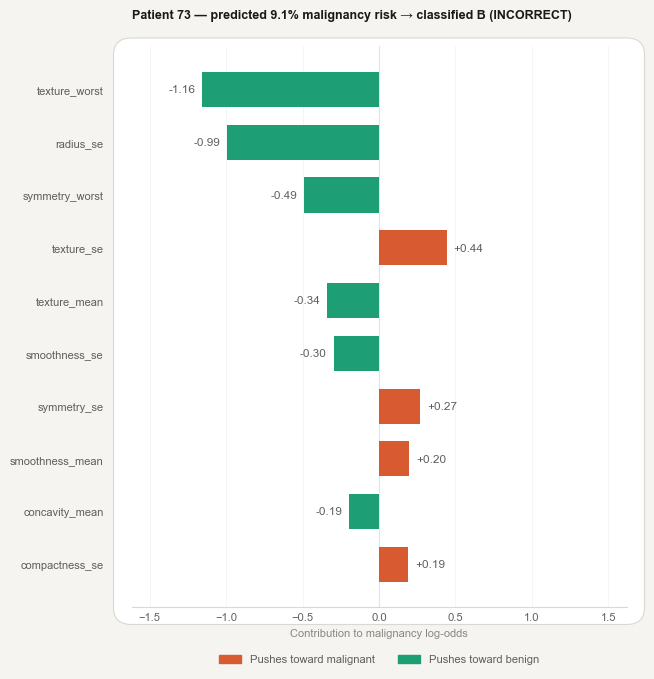

In [37]:
if __name__ == "__main__":
    model, scaler, X, X_train_raw, X_test_raw, y_train, y_test = train_final_model()
 
    # Combine train+test raw features so any index in the original dataset can be looked up
    X_all_raw = pd.concat([X_train_raw, X_test_raw]).sort_index()
    y_all     = pd.concat([y_train, y_test]).sort_index()
 
    figs = []
    for idx in PATIENT_INDICES:
        true_label = y_all.loc[idx]
        patient_row = X_all_raw.loc[idx]
 
        result = explain_patient(model, scaler, FINAL_FEATURES, patient_row)
        print_explanation(idx, true_label, result)
 
        fig = plot_patient_contributions(
            idx, true_label, result,
            save_path=f"patient_{idx}_contributions.png"
        )
        figs.append(fig)
        print("=" * 70 + "\n")
 
    plt.show()